<a href="https://colab.research.google.com/github/mrabinayaa/DAAexps/blob/main/exp4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

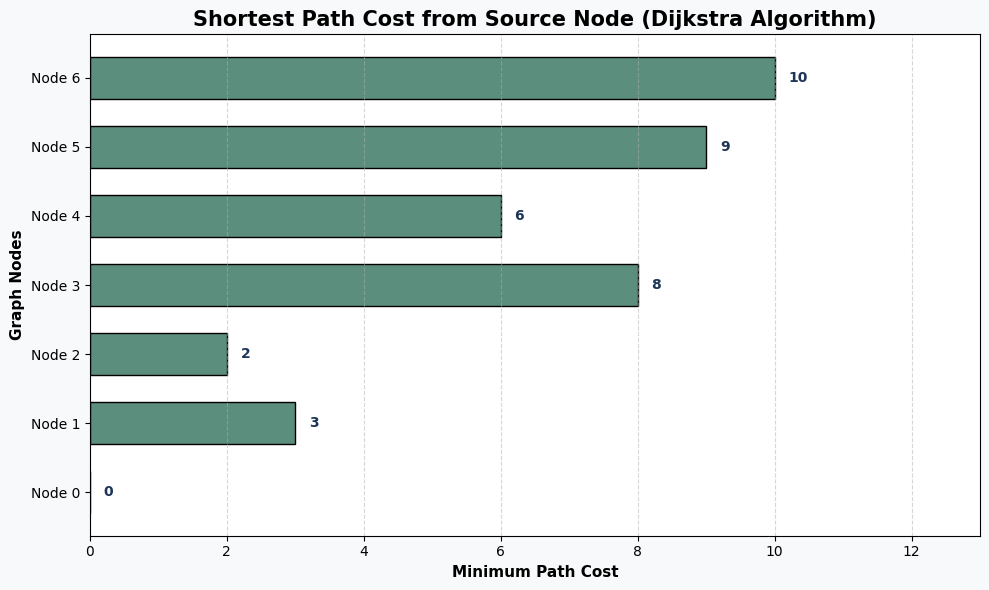

In [2]:
import heapq
import matplotlib.pyplot as plt

# -------------------- Dijkstra Algorithm --------------------

def shortest_path(graph, start):

    distance = {vertex: float('inf') for vertex in graph}
    distance[start] = 0

    queue = [(0, start)]
    visited = set()

    while queue:

        current_cost, current_vertex = heapq.heappop(queue)

        if current_vertex in visited:
            continue

        visited.add(current_vertex)

        for neighbour, weight in graph[current_vertex]:

            new_cost = current_cost + weight

            if new_cost < distance[neighbour]:
                distance[neighbour] = new_cost
                heapq.heappush(queue, (new_cost, neighbour))

    return distance


# -------------------- Graph Definition --------------------

graph = {
    0: [(1, 6), (2, 2)],
    1: [(3, 5), (4, 3)],
    2: [(1, 1), (3, 8), (5, 7)],
    3: [(4, 2), (6, 6)],
    4: [(6, 4)],
    5: [(4, 3), (6, 5)],
    6: []
}


# -------------------- Find Shortest Paths --------------------

result = shortest_path(graph, 0)

nodes = [f"Node {i}" for i in sorted(result.keys())]
costs = [result[i] for i in sorted(result.keys())]


# -------------------- Plot Result --------------------

plt.figure(figsize=(10,6), facecolor="#F8F9FA")
ax = plt.gca()
ax.set_facecolor("#FFFFFF")

bars = plt.barh(
    nodes,
    costs,
    color="#5B8E7D",
    edgecolor="black",
    height=0.6
)

# Display values on bars
for bar, value in zip(bars, costs):

    plt.text(
        value + 0.2,
        bar.get_y() + bar.get_height()/2,
        str(value),
        va="center",
        fontsize=10,
        fontweight="bold",
        color="#1D3557"
    )

plt.title(
    "Shortest Path Cost from Source Node (Dijkstra Algorithm)",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel(
    "Minimum Path Cost",
    fontsize=11,
    fontweight="bold"
)

plt.ylabel(
    "Graph Nodes",
    fontsize=11,
    fontweight="bold"
)

plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.xlim(0, max(costs) + 3)

plt.tight_layout()
plt.show()